In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


In [2]:
df=pd.read_csv("C:/Users/hp/Desktop/heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
828,44,1,2,130,233,0,1,179,1,0.4,2,0,2,1
452,66,0,0,178,228,1,1,165,1,1.0,1,2,3,0
22,45,1,0,104,208,0,0,148,1,3.0,1,0,2,1
1017,53,1,0,123,282,0,1,95,1,2.0,1,2,3,0
346,50,1,0,150,243,0,0,128,0,2.6,1,0,3,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df=df.drop_duplicates()
print(f"Duplicates removed completely! Real clean row:{len(df)}")

Duplicates removed completely! Real clean row:302


In [9]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
723    False
733    False
739    False
843    False
878    False
Length: 302, dtype: bool

C:\Users\hp\AppData\Local\Temp\ipykernel_12104\1789547331.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2')


([<matplotlib.axis.XTick at 0x1ad11cb5d30>,
 [Text(0, 0, 'No Disease (0)'), Text(1, 0, 'Disease (1)')])

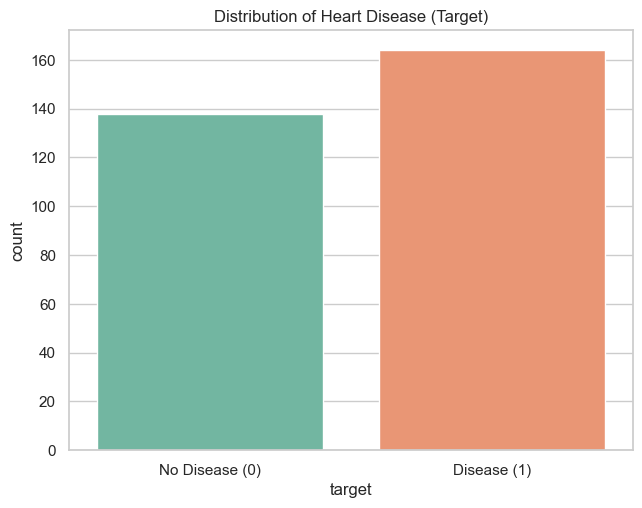

In [10]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# 1. Target Class Balance
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Distribution of Heart Disease (Target)')
plt.xticks([0, 1], ['No Disease (0)', 'Disease (1)'])

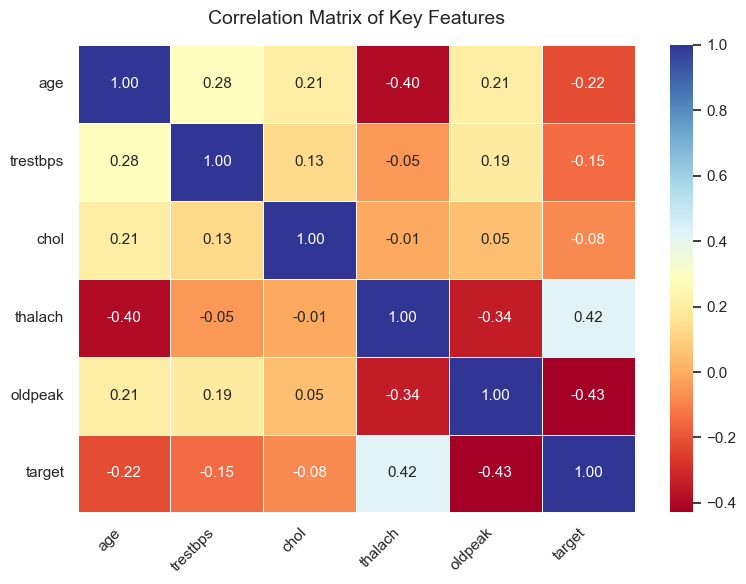

In [11]:
plt.figure(figsize=(8, 6))

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']
sns.heatmap(
    df[numerical_cols].corr(), 
    annot=True, 
    cmap='RdYlBu', 
    fmt=".2f",          # Limits to 2 decimal places
    linewidths=0.5, 
    annot_kws={"size": 11} # Shrinks font inside cells so they don't overlap
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title('Correlation Matrix of Key Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Age Distribution vs Heart Disease Status')

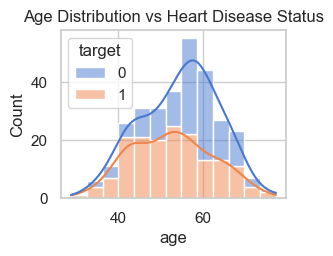

In [12]:
# 3. Age Distribution by Target
plt.subplot(2, 2, 4)
sns.histplot(data=df, x='age', hue='target', kde=True, multiple='stack', palette='muted')
plt.title('Age Distribution vs Heart Disease Status')

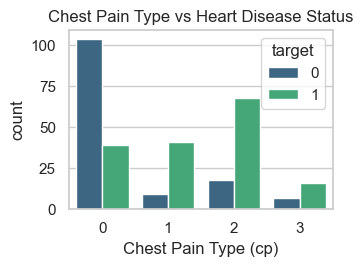

In [13]:
# 4. Chest Pain Type vs Target
plt.subplot(2, 2, 4)
sns.countplot(data=df, x='cp', hue='target', palette='viridis')
plt.title('Chest Pain Type vs Heart Disease Status')
plt.xlabel('Chest Pain Type (cp)')

plt.tight_layout()
plt.show()

In [14]:
x=df.drop('target',axis=1)
y=df['target']

In [15]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2


In [16]:
y

0      0
1      0
2      0
3      0
4      0
      ..
723    1
733    1
739    0
843    0
878    0
Name: target, Length: 302, dtype: int64

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# 1. Test Random Forest (handles encoded categorical data very well)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred) * 100:.2f}%")

# 2. Test Logistic Regression (excellent for small datasets, requires scaling)
lr_pipeline = make_pipeline(StandardScaler(), LogisticRegression(C=0.1, random_state=42))
lr_pipeline.fit(x_train, y_train)
lr_pred = lr_pipeline.predict(x_test)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred) * 100:.2f}%")

Random Forest Accuracy: 83.61%
Logistic Regression Accuracy: 80.33%


In [19]:
new_patient_data = {
    'age': 58,          
    'sex': 0,           # 1 = Male, 0 = Female
    'cp': 2,            # Chest pain type (0, 1, 2, 3)
    'trestbps': 130,    # Resting blood pressure
    'chol': 240,        # Serum cholesterol in mg/dl
    'fbs': 1,           # Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
    'restecg': 0,       # Resting electrocardiographic results (0, 1, 2)
    'thalach': 160,     # Maximum heart rate achieved
    'exang': 0,         # Exercise induced angina (1 = yes; 0 = no)
    'oldpeak': 0.6,     # ST depression induced by exercise relative to rest
    'slope': 1,         # The slope of the peak exercise ST segment
    'ca': 0,            # Number of major vessels (0-3) colored by fluoroscopy
    'thal': 2           # Thalassemia disorder type (1, 2, 3)
}

# 2. Convert the dictionary into a pandas DataFrame (1 row)
new_patient_df = pd.DataFrame([new_patient_data])

# 3. Make the hard prediction (0 or 1)
prediction = rf_model.predict(new_patient_df)

# 4.Probability score (how confident the model is)
probability = rf_model.predict_proba(new_patient_df)

# 5. Print out the results
print("--- Prediction Result ---")
if prediction[0] == 1:
    print(f"Result: HEART DISEASE DETECTED")
    print(f"Confidence: {probability[0][1] * 100:.2f}% risk probability")
else:
    print(f"Result: NO HEART DISEASE DETECTED")
    print(f"Confidence: {probability[0][0] * 100:.2f}% healthy probability")

--- Prediction Result ---
Result: HEART DISEASE DETECTED
Confidence: 84.05% risk probability


In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

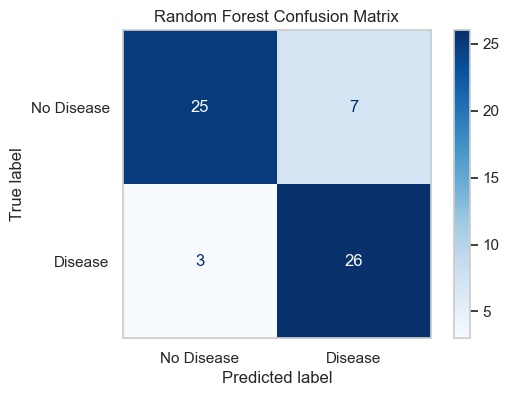

In [21]:
plt.figure(figsize=(6,4))
cm=confusion_matrix(y_test, rf_pred)
disp= ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title("Random Forest Confusion Matrix")
plt.grid(False)
plt.show()

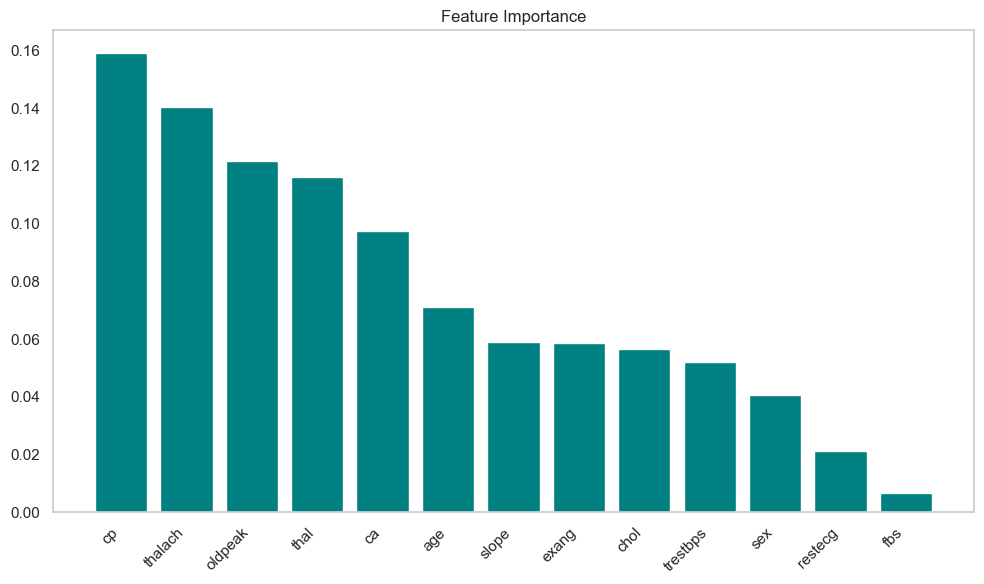

In [22]:
plt.figure(figsize=(10,6))
importances= rf_model.feature_importances_
indices= np.argsort(importances)[::-1]
plt.bar(range(x_train.shape[1]), importances[indices], align="center", color="teal")
plt.xticks(range(x_train.shape[1]), x_train.columns[indices], rotation=45, ha='right')
plt.title("Feature Importance")
plt.tight_layout()
plt.grid(False)
plt.show()

In [24]:
import pickle
with open('heart_disease_model.pkl','wb') as f:
    pickle.dump(rf_model, f)

In [26]:
%%writefile heart_app.py
import streamlit as st
import pickle
import pandas as pd
import numpy as np

# 1. Page Configuration
st.set_page_config(page_title="Interactive Heart Predictor", page_icon=":heart:", layout="centered")
st.title(":heart: Live Heart Disease Risk Predictor")
st.write("Move any slider or change any value below. The risk calculation updates instantly!")

# 2. Load the Saved Model
@st.cache_resource
def load_model():
    with open('heart_disease_model.pkl', 'rb') as f:
        return pickle.load(f)

model = load_model()

# 3. Create Input Forms arranged in Columns
col1, col2 = st.columns(2)

with col1:
    age = st.slider("Age (years)", 20, 90, 54)
    sex = st.selectbox("Sex", options=[1, 0], format_func=lambda x: "Male" if x == 1 else "Female")
    cp = st.selectbox("Chest Pain Type (cp)", options=[0, 1, 2, 3], format_func=lambda x: f"Type {x}")
    trestbps = st.slider("Resting Blood Pressure (trestbps)", 90, 200, 130)
    chol = st.slider("Serum Cholesterol (chol)", 100, 450, 240)
    fbs = st.selectbox("Fasting Blood Sugar > 120 mg/dl (fbs)", options=[0, 1], format_func=lambda x: "True" if x == 1 else "False")

with col2:
    restecg = st.selectbox("Resting Electrocardiographic Results (restecg)", options=[0, 1, 2])
    thalach = st.slider("Maximum Heart Rate Achieved (thalach)", 60, 220, 150)
    exang = st.selectbox("Exercise Induced Angina (exang)", options=[1, 0], format_func=lambda x: "Yes" if x == 1 else "No")
    oldpeak = st.slider("ST Depression (oldpeak)", 0.0, 6.0, 1.0, step=0.1)
    slope = st.selectbox("Slope of Peak Exercise ST Segment (slope)", options=[0, 1, 2])
    ca = st.selectbox("Number of Major Vessels Colored (ca)", options=[0, 1, 2, 3, 4])
    thal = st.selectbox("Thalassemia Type (thal)", options=[0, 1, 2, 3])

# 4. Instant Live Processing (No Button Required)
input_df = pd.DataFrame([{
    'age': age, 'sex': sex, 'cp': cp, 'trestbps': trestbps, 'chol': chol,
    'fbs': fbs, 'restecg': restecg, 'thalach': thalach, 'exang': exang,
    'oldpeak': oldpeak, 'slope': slope, 'ca': ca, 'thal': thal
}])

prediction = model.predict(input_df)
probability = model.predict_proba(input_df)[0][1] * 100

st.markdown("---")
st.subheader("📊 Live Assessment Result")

# Dynamic metric gauge summary
if prediction == 1:
    st.error(f"⚠️ **Heart Disease Risk Detected**")
    st.metric(label="Calculated Risk Probability", value=f"{probability:.1f}%")
    st.progress(int(probability))
else:
    st.success(f"✅ **No Heart Disease Risk Detected**")
    st.metric(label="Calculated Healthy Probability", value=f"{100 - probability:.1f}%")
    st.progress(int(100 - probability))

Writing heart_app.py
